In [ ]:
# pip install seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [2]:
df = pd.read_parquet("DKHousingPrices.parquet", engine='fastparquet')

In [3]:
# Drop null values in specified columns
df = df.dropna(subset=["city", "quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "area", "dk_ann_infl_rate%", "nom_interest_rate%", "yield_on_mortgage_credit_bonds%"])
df.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
1193,2024-09-30,218,1300,Apartment,regular_sale,1971,1765000,0.0,3,78.0,22628.205078,"Hedekæret 38, 1. th",2640,Hedehusene,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1194,2024-09-30,218,1307,Summerhouse,regular_sale,2009,590939,0.0,3,50.0,11818.780273,Violstien 11,2635,Ishøj,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1195,2024-09-30,218,1301,Apartment,regular_sale,1940,1750000,0.0,2,56.0,31250.000000,"Buddingevej 72I, st. tv",2800,Kongens Lyngby,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1196,2024-09-30,218,1302,Summerhouse,family_sale,1950,1080000,0.0,4,72.0,15000.000000,Frederiksvej 35,3730,Nexø,Bornholm,Bornholm,3.35,1.13,4.34
1197,2024-09-30,218,1303,Apartment,regular_sale,1974,2300000,0.0,1,50.0,46000.000000,"Thyrasgade 4, 4. 508",2200,København N,"Capital, Copenhagen",Zealand,3.35,1.13,4.34


### Purchase Price Plot

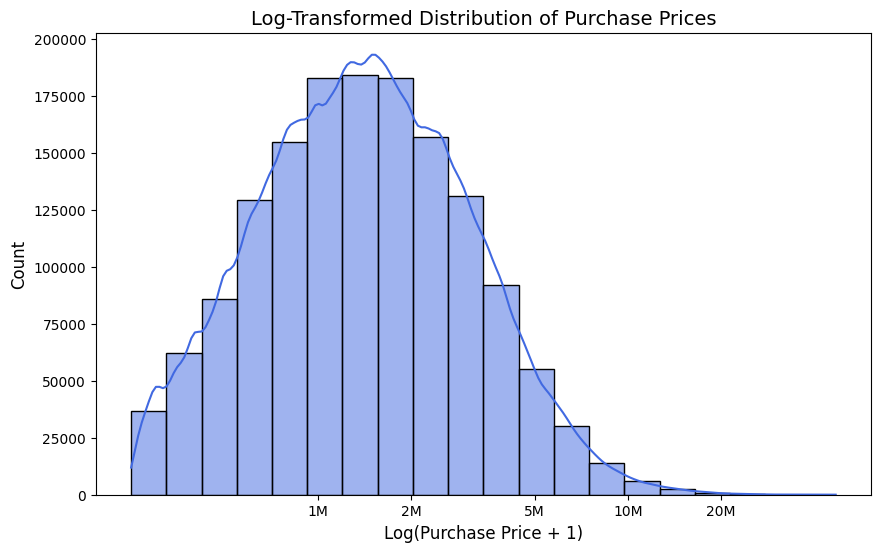

In [7]:
plt.figure(figsize=(10, 6))
# Log-transformer data (tilføj 1 for at undgå log(0))
sns.histplot(np.log1p(df['purchase_price']), bins=20, kde=True, color='royalblue')
plt.title('Log-Transformed Distribution of Purchase Prices', fontsize=14)
plt.xlabel('Log(Purchase Price + 1)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Tilføj originale x-aksens værdier som ticks
xticks = [1000000, 2000000, 5000000, 10000000, 20000000]
plt.xticks(ticks=np.log1p(xticks), labels=[f'{x/1e6:.0f}M' for x in xticks])

plt.show()


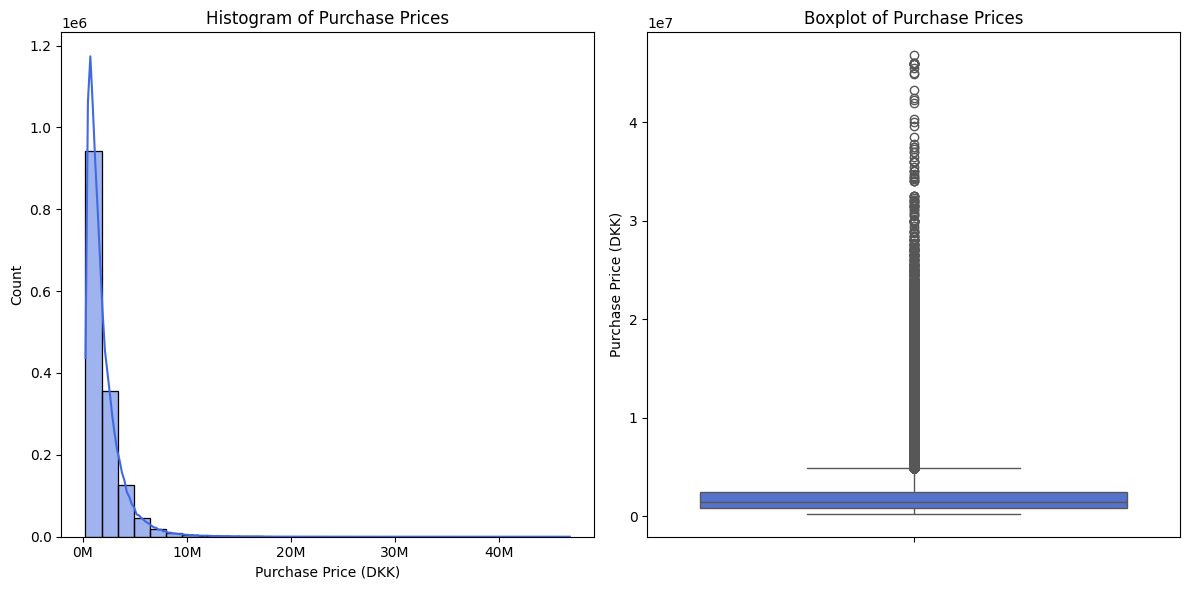

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['purchase_price'], bins=30, kde=True, color='royalblue')
plt.title('Histogram of Purchase Prices', fontsize=12)
plt.xlabel('Purchase Price (DKK)', fontsize=10)

plt.subplot(1, 2, 2)
sns.boxplot(y=df['purchase_price'], color='royalblue')
plt.title('Boxplot of Purchase Prices', fontsize=12)
plt.ylabel('Purchase Price (DKK)', fontsize=10)

# Formater x-aksen på histogrammet
def millions(x, pos):
    return f'{x/1e6:.0f}M'
formatter = FuncFormatter(millions)
plt.subplot(1, 2, 1).xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### Distribution of House Type

C:\Users\bpmro\AppData\Local\Temp\ipykernel_24712\1155830968.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='house_type', palette='viridis')


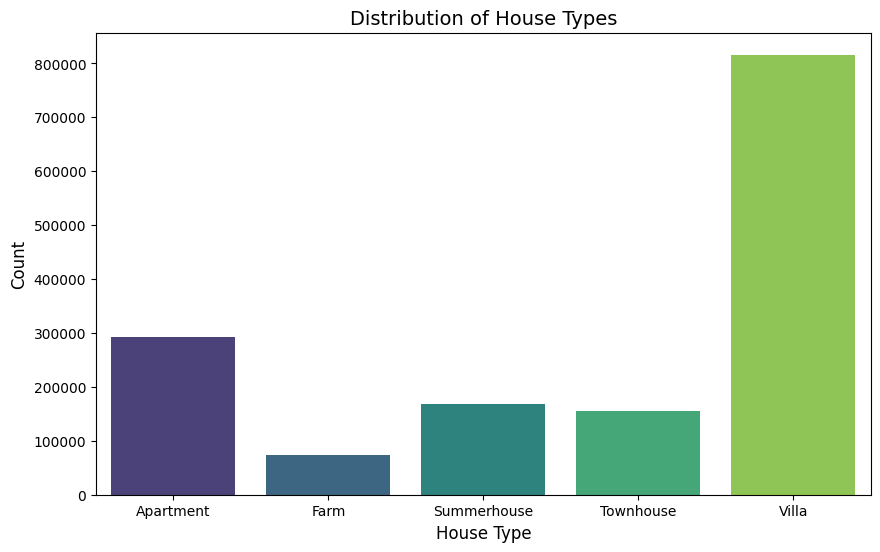

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='house_type', palette='viridis')
plt.title('Distribution of House Types', fontsize=14)
plt.xlabel('House Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Distribution of House Prices By Region

/tmp/ipykernel_25730/585410053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='purchase_price', errorbar=None, palette='coolwarm')


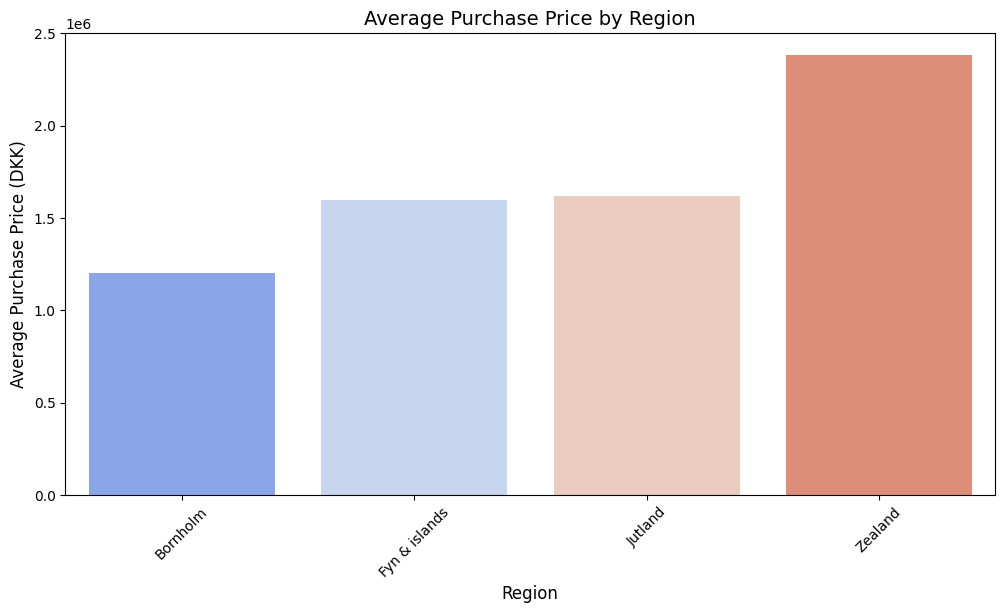

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='region', y='purchase_price', errorbar=None, palette='coolwarm')
plt.title('Average Purchase Price by Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Purchase Price (DKK)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Sqm vs Purchase Price

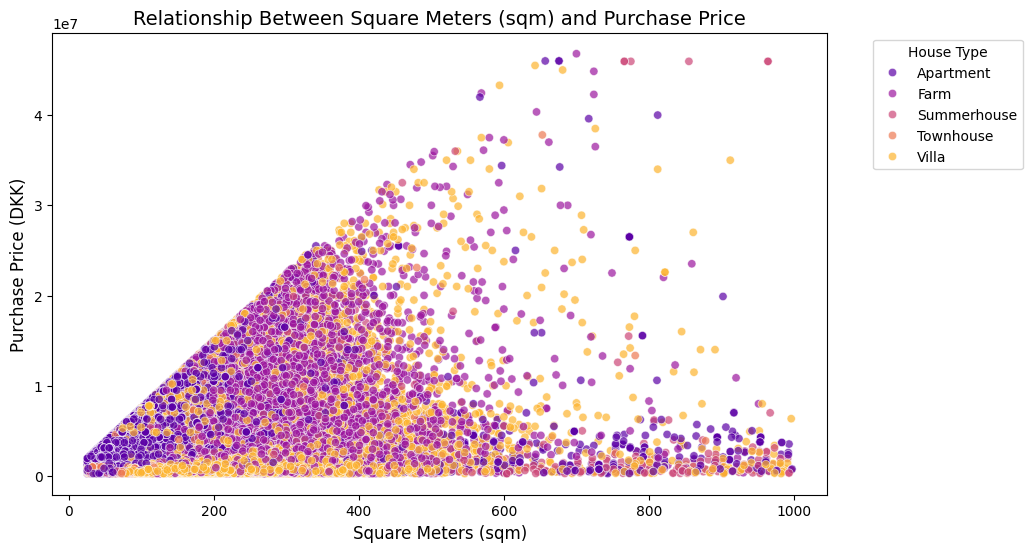

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sqm', y='purchase_price', hue='house_type', palette='plasma', alpha=0.7)
plt.title('Relationship Between Square Meters (sqm) and Purchase Price', fontsize=14)
plt.xlabel('Square Meters (sqm)', fontsize=12)
plt.ylabel('Purchase Price (DKK)', fontsize=12)
plt.legend(title='House Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Average Purchase Price by year of construction

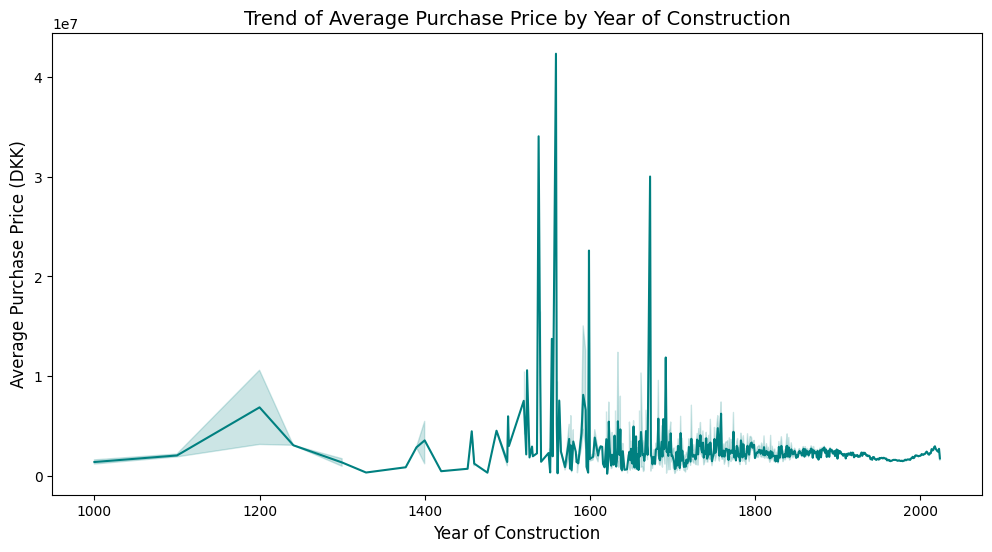

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='year_build', y='purchase_price', color='teal')
plt.title('Trend of Average Purchase Price by Year of Construction', fontsize=14)
plt.xlabel('Year of Construction', fontsize=12)
plt.ylabel('Average Purchase Price (DKK)', fontsize=12)
plt.show()

### Distribution of Number Of Rooms

/tmp/ipykernel_25730/3515517480.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='no_rooms', palette='pastel')


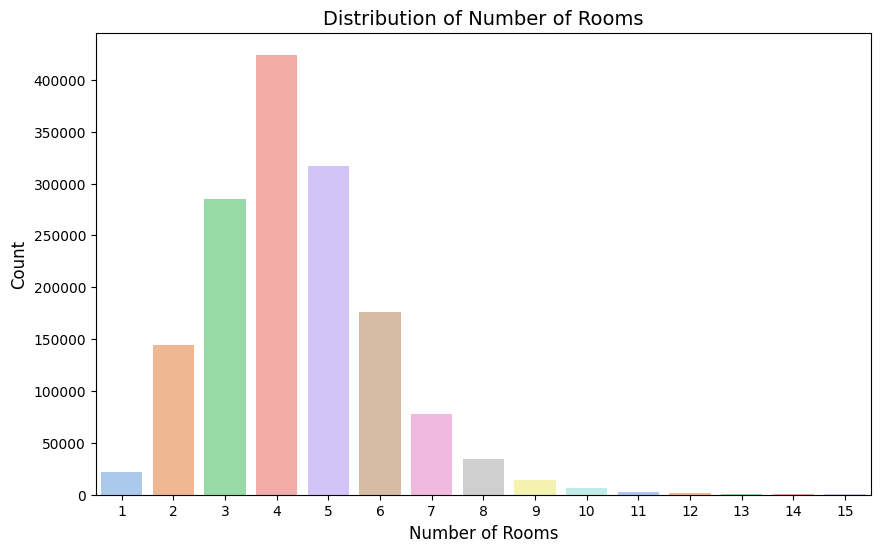

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='no_rooms', palette='pastel')
plt.title('Distribution of Number of Rooms', fontsize=14)
plt.xlabel('Number of Rooms', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Average Square meter price by House Type

/tmp/ipykernel_25730/75131645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='house_type', y='sqm_price', palette='muted', errorbar=None)


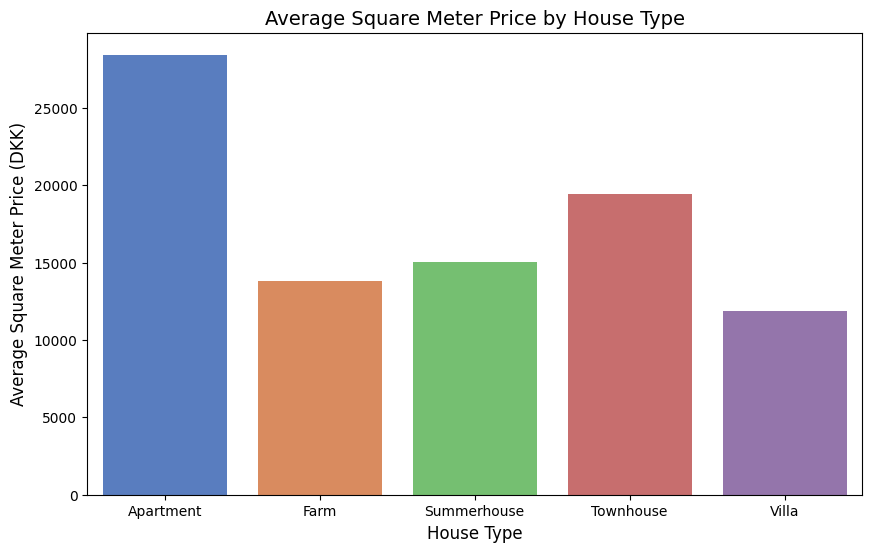

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='house_type', y='sqm_price', palette='muted', errorbar=None)
plt.title('Average Square Meter Price by House Type', fontsize=14)
plt.xlabel('House Type', fontsize=12)
plt.ylabel('Average Square Meter Price (DKK)', fontsize=12)
plt.show()

### Average Purchase Price by Sales Type

/tmp/ipykernel_25730/4210528795.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sales_type', y='purchase_price', palette='Spectral', errorbar=None)


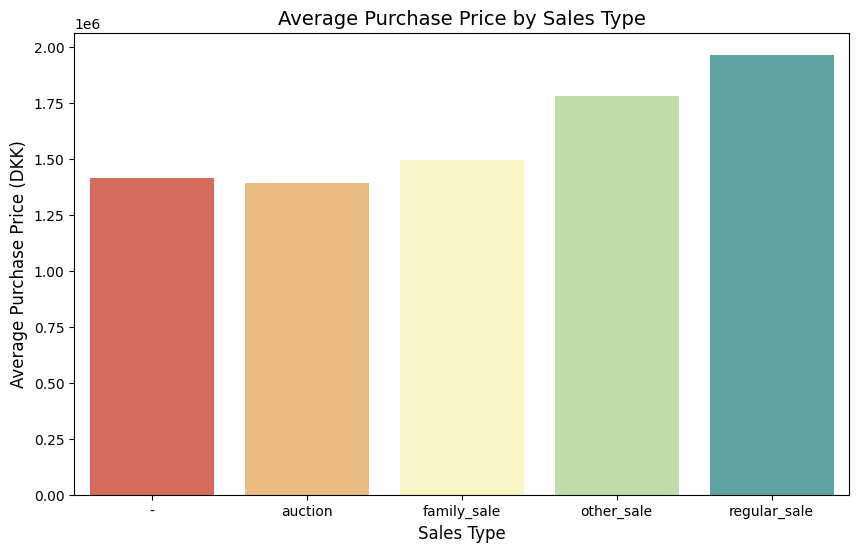

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sales_type', y='purchase_price', palette='Spectral', errorbar=None)
plt.title('Average Purchase Price by Sales Type', fontsize=14)
plt.xlabel('Sales Type', fontsize=12)
plt.ylabel('Average Purchase Price (DKK)', fontsize=12)
plt.show()

### Heatmap of Parameter Correlations

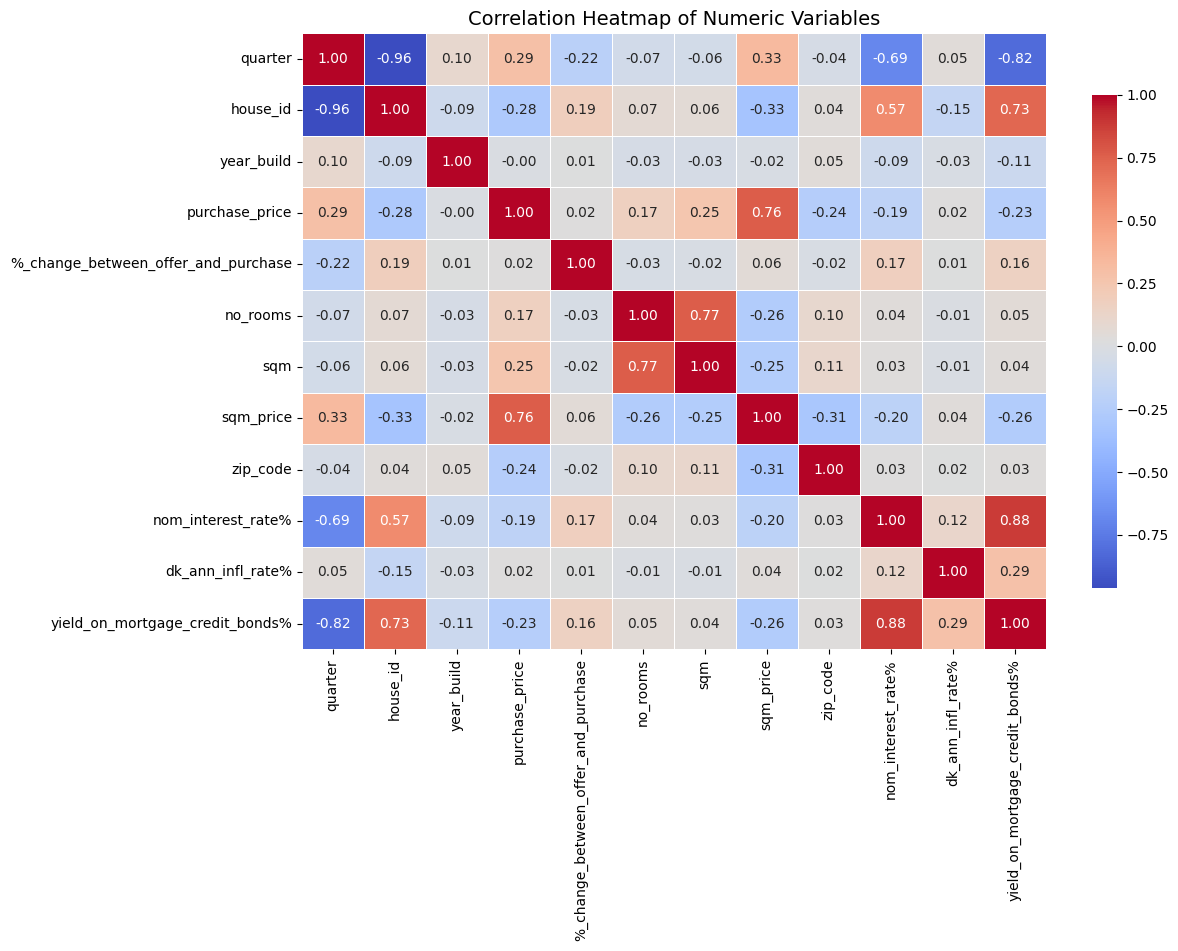

In [22]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.show()